In [1]:
import numpy as np
from scipy.stats import uniform
import matplotlib.pyplot as plt

import pymc as pm
import arviz as az
import os
import pandas as pd

In [2]:
version = 'vpce1.1'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')
   
# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius [cm]','Thickness [cm]','NPanels', 'Angle [deg]', 'Length [cm]']

y_label_sim = 'rGe77[nuc/(kg*yr)]'
y_label_cnp = "Ge-77_CNP"

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,2,4,0,1]
xhigh=[250,15,360,90,150]

LF_noise = 0.028
data=pd.read_csv(f'in/{file_in}')

In [3]:
x_lf, x_hf, y_lf, y_hf = ([],[],[],[])
row_h=data.index[data['Mode'] == 1]
row_l=data.index[data['Mode'] == 0]

x_hf = data.loc[data['Mode']==1.][x_labels].to_numpy()
y_hf = data.loc[data['Mode']==1.][y_label_sim].to_numpy()

x_mf = data.loc[data['Mode']==1.][x_labels].to_numpy()
y_mf = data.loc[data['Mode']==1.][y_label_cnp].to_numpy()

x_lf = data.loc[data['Mode']==0.][x_labels].to_numpy()
y_lf = data.loc[data['Mode']==0.][y_label_cnp].to_numpy()

In [4]:
print(x_hf)

[[  0.    0.    0.    0.    0. ]
 [ 95.   10.  360.    0.    1.7]
 [200.   10.  360.    0.    3.5]
 [116.2   1.1  52.   39.6  35.7]
 [183.8   5.1 219.   49.   19.8]
 [184.2   5.1 218.   48.9  17.8]
 [202.4   2.7  29.   10.4  78.7]
 [208.4   4.3  18.    3.   50.6]
 [225.2   9.6   7.    0.    3.5]
 [201.4   2.6 317.   52.1  16.6]]


In [5]:
# Generate synthetic data
np.random.seed(42)
n_samples = 100

In [6]:
data=pd.read_csv("./in/hf_validation_data_v1.2.csv")
x_data = data.loc[data['Mode']==1.][x_labels].to_numpy()
y_true = data.loc[data['Mode']==1.][y_label_sim].to_numpy()
y_true_cnp=data.loc[data['Mode']==1.][y_label_cnp].to_numpy()


In [7]:
from itertools import product, combinations

In [8]:
# Generate multivariate Legendre polynomial basis with interaction terms
def multivariate_legendre_with_interactions(order, x):
    """Generate multivariate Legendre polynomial basis with interactions."""
    n_samples, n_features = x.shape
    degrees = list(product(range(order + 1), repeat=n_features))
    basis = []
    for degree in degrees:
        term = np.ones(n_samples)
        for i, d in enumerate(degree):
            term *= np.polynomial.legendre.Legendre.basis(d)(x[:, i])
        basis.append(term)
    
    # Add interaction terms
    for i, j in combinations(range(n_features), 2):
        basis.append(x[:, i] * x[:, j])
    
    return np.vstack(basis).T

In [9]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

In [10]:
def cross_validate_order(x_lf, y_lf, x_hf, y_hf, max_order=5):
    errors = []
    kf = KFold(n_splits=5)
    for order in range(1, max_order + 1):
        phi_lf = multivariate_legendre_with_interactions(order, x_lf)
        phi_hf = multivariate_legendre_with_interactions(order, x_hf)

        # Fit LF model
        c_lf = np.linalg.lstsq(phi_lf, y_lf, rcond=None)[0]
        
        y_lf_hf_pred = phi_hf @ c_lf
        delta_hf = y_hf - y_lf_hf_pred

        mse_fold = []
        for train_idx, test_idx in kf.split(x_hf):
            x_train, x_test = x_hf[train_idx], x_hf[test_idx]
            y_train, y_test = y_hf[train_idx], y_hf[test_idx]

            phi_train = multivariate_legendre_with_interactions(order, x_train)
            phi_test = multivariate_legendre_with_interactions(order, x_test)
            
            # Bayesian fit for HF correction
            c_hf = np.linalg.lstsq(phi_train, y_train - phi_train @ c_lf, rcond=None)[0]
            y_pred_fold = phi_test @ c_hf + phi_test @ c_lf
            mse_fold.append(mean_squared_error(y_test, y_pred_fold))
        
        errors.append(np.mean(mse_fold))
    return np.argmin(errors) + 1

In [11]:
# Cross-validate for optimal polynomial order
optimal_order = cross_validate_order(x_lf, y_lf, x_hf, y_hf, max_order=5)
print(f"Optimal Polynomial Order: {optimal_order}")

Optimal Polynomial Order: 1


In [12]:
from itertools import combinations_with_replacement
from numpy.polynomial.legendre import Legendre

In [13]:
def multivariate_legendre_basis(degree, x_data):
    """
    Generate the multivariate Legendre basis for multi-dimensional inputs.
    
    Parameters:
        x_data (ndarray): Input data of shape (n_samples, n_dim).
        degree (int): Maximum polynomial degree.
    
    Returns:
        basis_matrix (ndarray): Shape (n_samples, n_terms).
    """
    n_samples, n_dim = x_data.shape
    terms = []
    
    # Generate all combinations of terms up to the given degree
    for deg in range(degree + 1):
        for combo in combinations_with_replacement(range(n_dim), deg):
            terms.append(combo)

    # Evaluate each term for all samples
    basis_matrix = np.zeros((n_samples, len(terms)))
    for i, term in enumerate(terms):
        poly = np.prod([Legendre.basis(1)(x_data[:, dim]) for dim in term], axis=0)
        basis_matrix[:, i] = poly

    return basis_matrix

In [14]:
def find_indices(x_hf, x_lf):
    """
    Finds the indices of x_hf in x_lf.

    Parameters:
        x_hf (numpy.ndarray): Array of high-fidelity x values.
        x_lf (numpy.ndarray): Array of low-fidelity x values.

    Returns:
        list: Indices of x_hf in x_lf.
    """
    indices = []
    for x in x_hf:
        # Find the index of the value in x_lf that matches x_hf
        idx = np.where((x_lf == x).all(axis=1))[0]
        if idx.size > 0:
            indices.append(idx[0])  # Append the index
        else:
            raise ValueError(f"Value {x} from x_hf not found in x_lf.")
    return indices

In [15]:
indices_mf = find_indices(x_mf, x_lf)
indices_hf = find_indices(x_hf, x_mf)
print(indices_hf)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


|coeffs_lf |rho_lf_mf| delta_mf | rho_mf_hf | delta_hf |sigma |1sigma|2sigma|3sigma|MSE    |
|:---------|---------|---------:|----------:|---------:|-----:|-----:|-----:|-----:|------:|
|   0+-0.5 | 1+-0.05 | 0+-0.05  | 1+-0.05   |  0+-0.05 | 0.01 |  1   |  4   |  10  |
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   |  0+-0.05 | 0.01 |  9   | 55   |  94  |
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   | 0+-0.005 | 0.01 | 80   | 92   |  96  |0.01051|
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   |  0+-0.01 | 0.01 | 30   | 86   |  90  |
|   0+-0.25| 1+-0.05 | 0+-0.005 | 1+-0.05   |0+-0.0075 | 0.01 |  6   | 26   |  47  |
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   |0+-0.008  | 0.01 |  72  | 91   |  96  |0.00347
|   0+-0.5 | 1+-0.05 | 0+-0.008 | 1+-0.05   |0+-0.008  | 0.01 |  19  | 63   |  83  |
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   |0+-0.0075 | 0.01 |  69  | 91   |  94  |0.00433|
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   |0+-0.0075 | 0.02 |  86  | 97   |  99  |0.00349|
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   |0+-0.006  | 0.01 |  19  | 68   |  97  |0.01259|
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   |0+-0.008  | 0.015|  95  | 98   |  99  |0.00174|
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   |0+-0.008  |0.0125|  51  |  98  |  100 |0.00732
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.05   |0+-0.01   | 0.015|  28  |  98  |  100 |0.01117|
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.08   |0+-0.008  | 0.01 |  66  | 91   | 97   |0.00394|
|   0+-0.5 | 1+-0.05 | 0+-0.005 | 1+-0.03   |0+-0.008  | 0.01 |  66  | 91   | 97   |0.00394|



In [16]:
# Define degree of PCE
degree = optimal_order
basis_matrix_hf = multivariate_legendre_basis(degree, x_hf)  # Shape: (100, 3)
basis_matrix_mf = multivariate_legendre_basis(degree, x_mf)  # Shape: (100, 3)
basis_matrix_lf = multivariate_legendre_basis(degree, x_lf)  # Shape: (100, 3)
indices_mf = find_indices(x_mf, x_lf)
indices_hf = find_indices(x_hf, x_mf)



# Bayesian model for PCE
with pm.Model() as model:
    #coeffs_lf = 0+-0.5, rho=1+-0.05, coeff_delta_mf=0+-0.05
    coeffs_lf = pm.Normal("coeffs_lf", mu=0, sigma=0.5, shape=basis_matrix_lf.shape[1])
    y_lf_pred_full = pm.Deterministic("y_lf_pred_full", pm.math.dot(basis_matrix_lf, coeffs_lf))  # Low-fidelity PCE
    y_lf_pred_subset = pm.Deterministic("y_lf_pred_subset", y_lf_pred_full[indices_mf])  # Shape: (10,)
    rho_lf_mf = pm.Normal("rho_lf_mf", mu=1, sigma=0.05)  # Prior for scaling factor
    coeffs_delta_mf = pm.Normal("coeffs_delta_mf", mu=0, sigma=0.005, shape=basis_matrix_mf.shape[1])
    delta_pred_mf = pm.Deterministic("delta_pred_mf", pm.math.dot(basis_matrix_mf, coeffs_delta_mf))
    # Medium-fidelity predictions
    y_mf_pred = pm.Deterministic("y_mf_pred", rho_lf_mf * y_lf_pred_subset + delta_pred_mf)
    y_mf_pred_subset = pm.Deterministic("y_mf_pred_subset", y_mf_pred[indices_hf])  # Shape: (10,)

    #rho=1+-0.05, coeff_delta_mf=0+-0.05
    rho_mf_hf = pm.Normal("rho_mf_hf", mu=1, sigma=0.05)  # Prior for scaling factor
    #coeffs_rho_mf_hf = pm.Normal("coeffs_rho_mf_hf", mu=1, sigma=0.05, shape=basis_matrix_hf.shape[1])
    #rho_pred_mf_hf = pm.Deterministic("rho_pred_mf_hf", pm.math.dot(basis_matrix_hf, coeffs_rho_mf_hf))
    
    coeffs_delta_hf = pm.Normal("coeffs_delta_hf", mu=0, sigma=0.005, shape=basis_matrix_hf.shape[1])
    delta_pred_hf = pm.Deterministic("delta_pred_hf", pm.math.dot(basis_matrix_hf, coeffs_delta_hf))
    y_hf_pred = pm.Deterministic("y_hf_pred", rho_mf_hf * y_mf_pred_subset + delta_pred_hf)

    #sigma_hf=0.01
    # Likelihood for high-fidelity data
    sigma_hf = pm.HalfNormal("sigma_hf", sigma=0.01)  # Prior for noise
    y_like_hf = pm.Normal("y_like_hf", mu=y_hf_pred, sigma=sigma_hf, observed=y_hf)  # Observed high-fidelity data

    # Inference
    # trace = pm.sample(10000, tune=2000, target_accept=0.95, cores=4, return_inferencedata=True, progressbar=True)

    # Inference with Variational Inference
    approx = pm.fit(n=1000000, method="advi", progressbar=True)
    trace = approx.sample(20000)  # Generate samples from the approximation

/Users/aschuetz/.local/modules/miniconda/miniconda3/envs/pymc-env/lib/python3.10/site-packages/rich/live.py:231: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 238.56


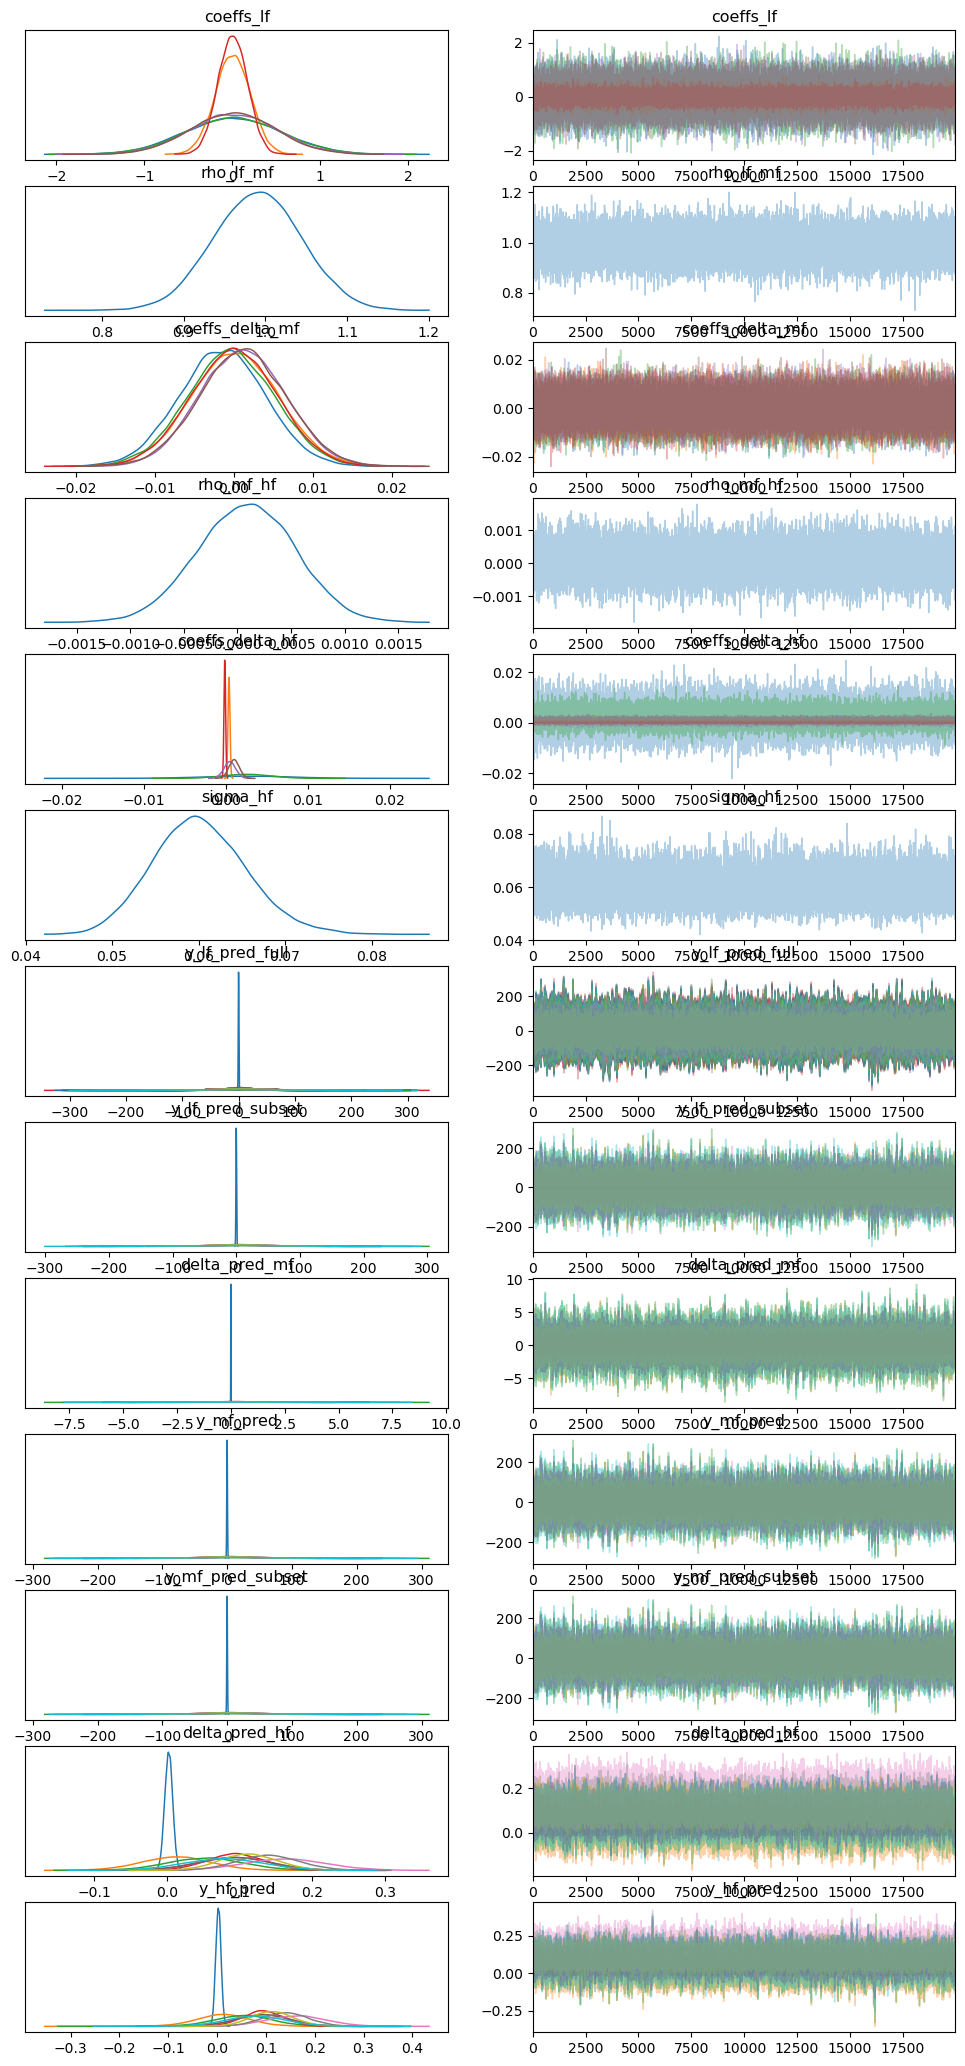

In [17]:

# Analyze results
az.plot_trace(trace)
plt.show()

# Posterior predictive samples
#with model:
#    ppc = pm.sample_posterior_predictive(trace, var_names=["y_lf_pred_full"])



arviz - WARNING - Shape validation failed: input_shape: (1, 20000), minimum_shape: (chains=2, draws=4)


array([[<Axes: title={'center': 'coeffs_delta_hf'}>,
        <Axes: title={'center': 'coeffs_delta_hf'}>]], dtype=object)

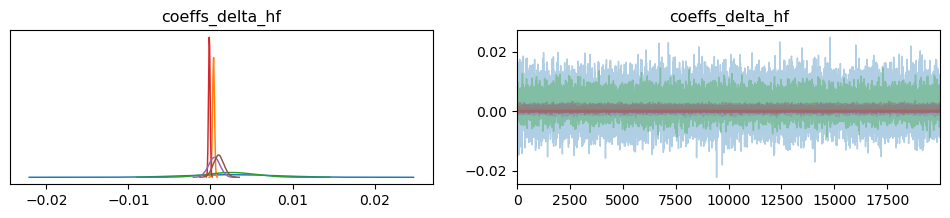

In [18]:
az.summary(trace, var_names=["coeffs_delta_hf"])
az.plot_trace(trace, var_names=["coeffs_delta_hf"])



In [19]:
# Define indices for medium-fidelity and high-fidelity samples
indices_mf = np.arange(len(x_data))  # Medium-fidelity indices
indices_hf = np.arange(len(x_data))  # High-fidelity indices

# Generate basis matrices
basis_matrix_lf = multivariate_legendre_basis(degree, x_data)  # Low-fidelity basis matrix
basis_matrix_mf = multivariate_legendre_basis(degree, x_data)  # Medium-fidelity basis matrix
basis_matrix_hf = multivariate_legendre_basis(degree, x_data)  # High-fidelity basis matrix

# Extract low-fidelity, medium-fidelity, and high-fidelity coefficients from the posterior
coeff_samples_lf = trace.posterior["coeffs_lf"].values  # Shape: (n_chains, n_draws, n_terms_lf)
coeff_samples_delta_mf = trace.posterior["coeffs_delta_mf"].values  # Shape: (n_chains, n_draws, n_terms_mf)
coeff_samples_delta_hf = trace.posterior["coeffs_delta_hf"].values  # Shape: (n_chains, n_draws, n_terms_hf)
rho_lf_mf_samples = trace.posterior["rho_lf_mf"].values  # Shape: (n_chains, n_draws)
rho_mf_hf_samples = trace.posterior["rho_mf_hf"].values  # Shape: (n_chains, n_draws)

# Flatten coefficients and scaling factors to combine chains and draws
coeff_samples_lf_flat = coeff_samples_lf.reshape(-1, coeff_samples_lf.shape[-1])  # Shape: (n_samples_total, n_terms_lf)
coeff_samples_delta_mf_flat = coeff_samples_delta_mf.reshape(-1, coeff_samples_delta_mf.shape[-1])  # Shape: (n_samples_total, n_terms_mf)
coeff_samples_delta_hf_flat = coeff_samples_delta_hf.reshape(-1, coeff_samples_delta_hf.shape[-1])  # Shape: (n_samples_total, n_terms_hf)
rho_lf_mf_samples_flat = rho_lf_mf_samples.flatten()  # Shape: (n_samples_total,)
rho_mf_hf_samples_flat = rho_mf_hf_samples.flatten()  # Shape: (n_samples_total,)

# Generate low-fidelity predictions
y_lf_pred_samples = np.dot(coeff_samples_lf_flat, basis_matrix_lf.T)  # Shape: (n_samples_total, n_lf_samples)

# Generate medium-fidelity predictions
delta_pred_mf_samples = np.dot(coeff_samples_delta_mf_flat, basis_matrix_mf.T)  # Shape: (n_samples_total, n_mf_samples)
y_mf_pred_samples = rho_lf_mf_samples_flat[:, None] * y_lf_pred_samples[:, indices_mf] + delta_pred_mf_samples  # Shape: (n_samples_total, n_mf_samples)

# Generate high-fidelity predictions
delta_pred_hf_samples = np.dot(coeff_samples_delta_hf_flat, basis_matrix_hf.T)  # Shape: (n_samples_total, n_hf_samples)
y_hf_pred_samples = rho_mf_hf_samples_flat[:, None] * y_mf_pred_samples[:, indices_hf] + delta_pred_hf_samples  # Shape: (n_samples_total, n_hf_samples)

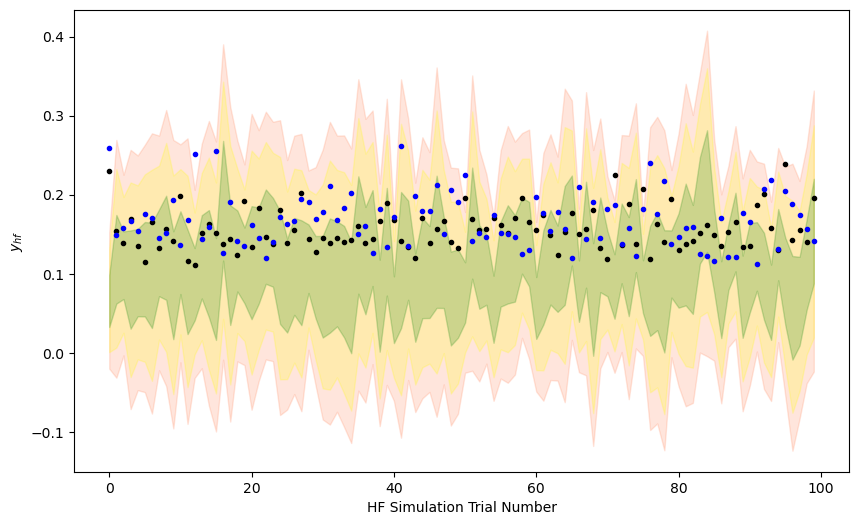

In [20]:
# Generate sample indices for HF samples
hf_sample_numbers = np.arange(len(y_true))  # Shape: (n_hf_samples,)

# Plot observed vs. predicted
plt.figure(figsize=(10, 6))
plt.fill_between(
    hf_sample_numbers,
    np.percentile(y_hf_pred_samples, 0.5, axis=0),
    np.percentile(y_hf_pred_samples, 99.5, axis=0),
    color="coral", alpha=0.2, label=r'$\pm 3\sigma$'
)
plt.fill_between(
    hf_sample_numbers,
    np.percentile(y_hf_pred_samples, 2.5, axis=0),
    np.percentile(y_hf_pred_samples, 97.5, axis=0),
    color="yellow", alpha=0.2, label=r'$\pm 2\sigma$'
)
plt.fill_between(
    hf_sample_numbers,
    np.percentile(y_hf_pred_samples, 16, axis=0),
    np.percentile(y_hf_pred_samples, 84, axis=0),
    color="green", alpha=0.2, label=r'PCE $\pm 1\sigma$'
)
plt.xlabel('HF Simulation Trial Number')
plt.ylabel(r'$y_{hf}$')
plt.scatter(hf_sample_numbers, y_true, marker='.', label="HF Validation Data", color="black")
plt.scatter(hf_sample_numbers, y_true_cnp, marker='.', label="HF Validation Data", color="blue")
handles, labels = plt.gca().get_legend_handles_labels()
order = [3, 2, 1, 0]
#plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order], loc=9, bbox_to_anchor=(0.665, 1.0), ncol=5)
plt.show()

In [21]:
counter_1sigma = 0
counter_2sigma = 0
counter_3sigma = 0
y_pred=np.mean(y_hf_pred_samples, axis=0)
y_1sigma_low = np.percentile(y_hf_pred_samples, 16, axis=0)
y_1sigma_high = np.percentile(y_hf_pred_samples, 84, axis=0)
y_2sigma_low = np.percentile(y_hf_pred_samples, 2.5, axis=0)
y_2sigma_high = np.percentile(y_hf_pred_samples, 97.5, axis=0)
y_3sigma_low = np.percentile(y_hf_pred_samples, 0.5, axis=0)
y_3sigma_high = np.percentile(y_hf_pred_samples, 99.5, axis=0)
for i in range(len(y_true)):
        if (y_true[i] <= y_1sigma_high[i]) and (y_true[i] >= y_1sigma_low[i]):
                counter_1sigma += 1
        if (y_true[i] <= y_2sigma_high[i]) and (y_true[i] >= y_2sigma_low[i]):
                counter_2sigma += 1

        if (y_true[i] <= y_3sigma_high[i]) and (y_true[i] >= y_3sigma_low[i]):
                counter_3sigma += 1

        percentage_1sigma=counter_1sigma/len(y_true)*100.
        percentage_2sigma=counter_2sigma/len(y_true)*100.
        percentage_3sigma=counter_3sigma/len(y_true)*100.
print("1 sigma: ", percentage_1sigma," %" )
print("2 sigma: ", percentage_2sigma," %" )
print("3 sigma: ", percentage_3sigma," %" )

1 sigma:  68.0  %
2 sigma:  92.0  %
3 sigma:  95.0  %


In [22]:

MSE=0
NMSE=0
MAE=0
MSSE=0

for i in range(len(y_true)):
        MAE +=np.abs(y_true[i]-y_pred[i])
        MSE +=pow(y_true[i]-y_pred[i],2)
        y_std=y_1sigma_high[i]-y_1sigma_low[i]
        NMSE +=np.abs((y_true[i]-y_pred[i])/y_std)
        MSSE +=pow((y_true[i]-y_pred[i])/y_std,2)
        
MAE=MAE/len(y_true)
mse = mean_squared_error(y_true,y_pred, squared=True)
NMSE=NMSE/len(y_true)
MSSE=MSSE/len(y_true)

MSE=MSE/len(y_true)
means = [percentage_1sigma,percentage_2sigma,percentage_3sigma,MAE,NMSE,MSE,MSSE]
print(f"B-PCE & {n_samples} & 0 & {''.join([f'{x:.5f} & ' for x in means])} \\\ \hline\n")

B-PCE & 100 & 0 & 68.00000 & 92.00000 & 95.00000 & 0.04895 & 0.46187 & 0.00371 & 0.40201 &  \\ \hline

